# Importing the required libraries and dataset from google drive

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [2]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error)
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import shapiro
from statsmodels.stats.diagnostic import het_breuschpagan

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df = pd.read_csv('/content/drive/MyDrive/Assessments   projects/Third Project (Predictive Modeling with Linear Regression)/ottdata.csv')

# Exploratory Data Analysis

## Data Overview

In [5]:
df.head()

,visitors,ad_impressions,major_sports_event,genre,dayofweek,season,views_trailer,views_content
0,1.67,1113.81,0,Horror,Wednesday,Spring,56.70,0.51
1,1.46,1498.41,1,Thriller,Friday,Fall,52.69,0.32
2,1.47,1079.19,1,Thriller,Wednesday,Fall,48.74,0.39
3,1.85,1342.77,1,Sci-Fi,Friday,Fall,49.81,0.44
4,1.46,1498.41,0,Sci-Fi,Sunday,Winter,55.83,0.46


In [6]:
df.shape

(1000, 8)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   visitors            1000 non-null   float64
 1   ad_impressions      1000 non-null   float64
 2   major_sports_event  1000 non-null   int64  
 3   genre               1000 non-null   object 
 4   dayofweek           1000 non-null   object 
 5   season              1000 non-null   object 
 6   views_trailer       1000 non-null   float64
 7   views_content       1000 non-null   float64
dtypes: float64(4), int64(1), object(3)
memory usage: 62.6+ KB


In [8]:
df.describe()

,visitors,ad_impressions,major_sports_event,views_trailer,views_content
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,1.704290,1434.712290,0.400000,66.91559,0.473400
std,0.231973,289.534834,0.490143,35.00108,0.105914
min,1.250000,1010.870000,0.000000,30.08000,0.220000
25%,1.550000,1210.330000,0.000000,50.94750,0.400000
50%,1.700000,1383.580000,0.000000,53.96000,0.450000
75%,1.830000,1623.670000,1.000000,57.75500,0.520000
max,2.340000,2424.200000,1.000000,199.92000,0.890000


## Data Background

In [9]:
df.columns

Index(['visitors', 'ad_impressions', 'major_sports_event', 'genre',
       'dayofweek', 'season', 'views_trailer', 'views_content'],
      dtype='object')


## Problem Definition

ShowTime wants to identify the important factors affecting
first-day content viewership on its OTT platform.

Target Variable:
views_content

Business Goal:
Build insights and identify driver variables influencing
content performance.

## Univariate Analysis

### 1. Distribution of content views

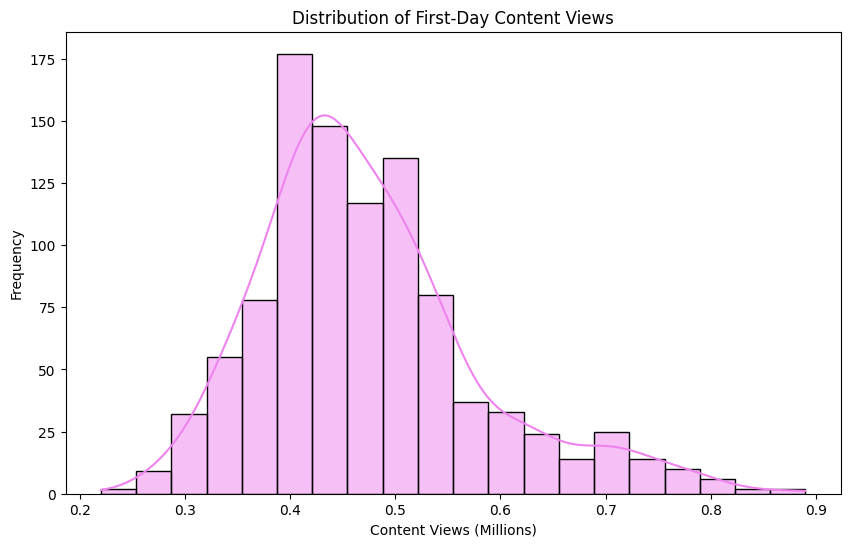

In [10]:
plt.figure(figsize=(10,6))
sns.histplot(df['views_content'], bins=20, kde=True, color='Violet')
plt.title('Distribution of First-Day Content Views')
plt.xlabel('Content Views (Millions)')
plt.ylabel('Frequency')
plt.show()

### 2. Distribution of trailer views

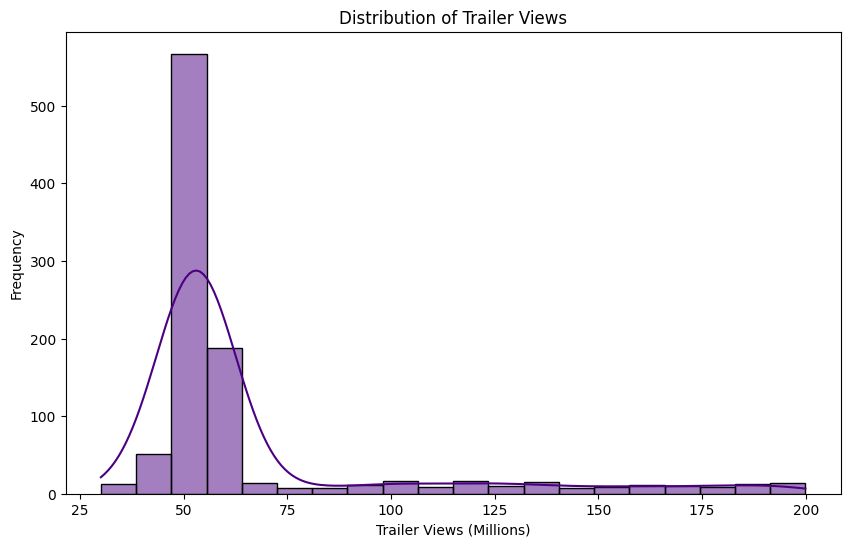

In [11]:
plt.figure(figsize=(10,6))
sns.histplot(df['views_trailer'], bins=20, kde=True, color='Indigo')
plt.title('Distribution of Trailer Views')
plt.xlabel('Trailer Views (Millions)')
plt.ylabel('Frequency')
plt.show()

### 3. Distribution of visitors

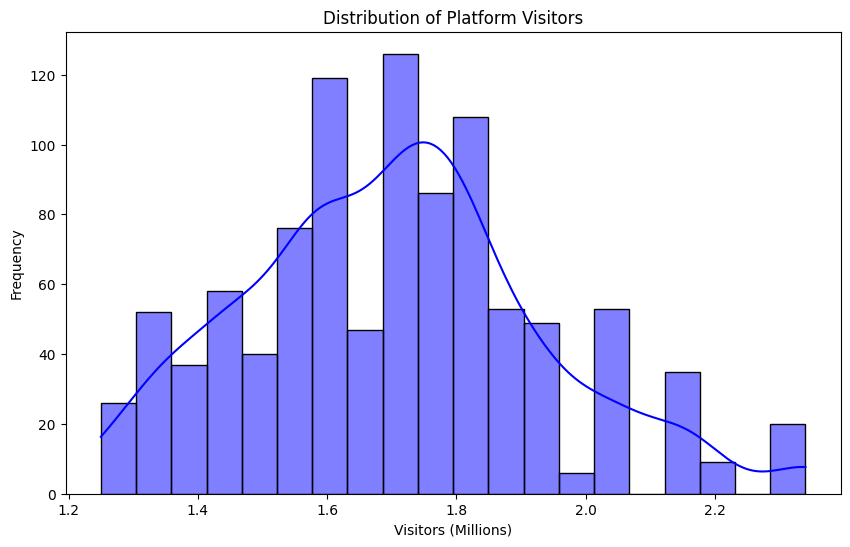

In [12]:
plt.figure(figsize=(10,6))
sns.histplot(df['visitors'], bins=20, kde=True, color='Blue')
plt.title('Distribution of Platform Visitors')
plt.xlabel('Visitors (Millions)')
plt.ylabel('Frequency')
plt.show()

### 4. Distribution of impressions

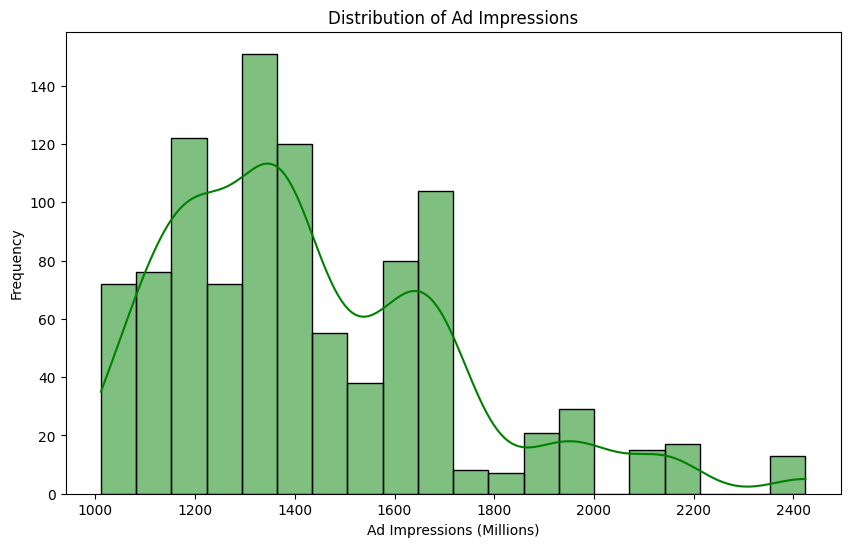

In [13]:
plt.figure(figsize=(10,6))
sns.histplot(df['ad_impressions'], bins=20, kde=True, color='Green')
plt.title('Distribution of Ad Impressions')
plt.xlabel('Ad Impressions (Millions)')
plt.ylabel('Frequency')
plt.show()

### 5. Genre distribution

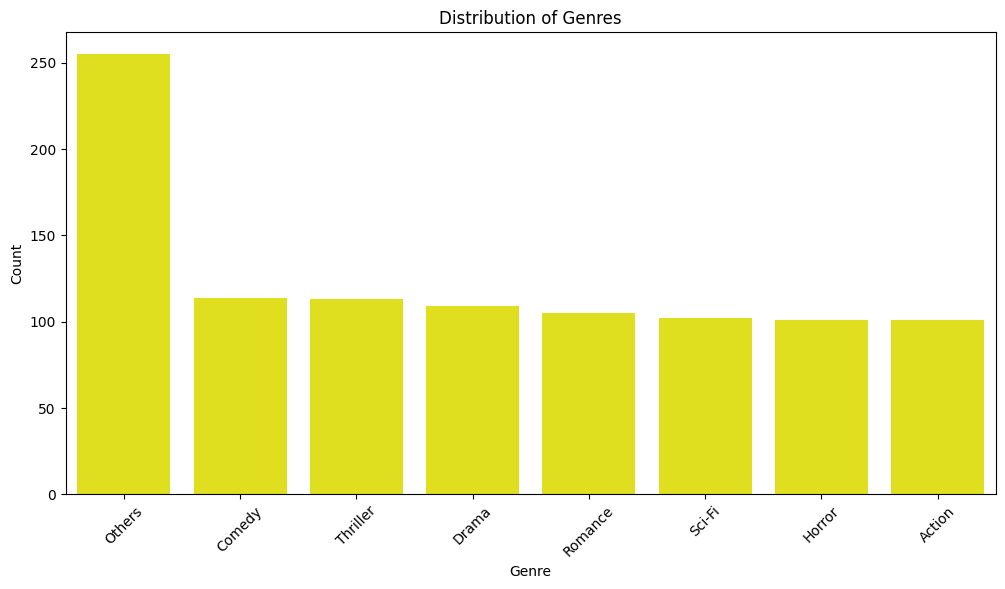

In [14]:
plt.figure(figsize=(12,6))
genre_count = df['genre'].value_counts()
sns.barplot(x=genre_count.index, y=genre_count.values, color='Yellow')
plt.title('Distribution of Genres')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

### 6. Day of week distribution

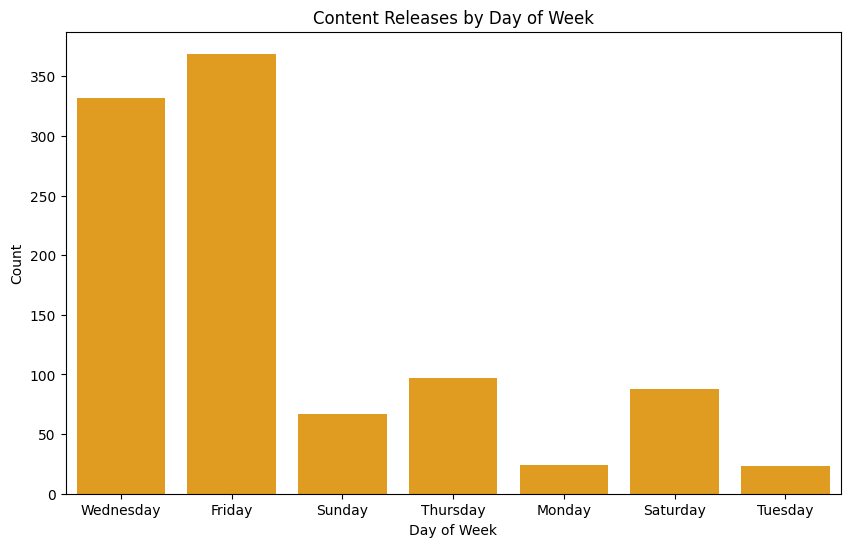

In [15]:
plt.figure(figsize=(10,6))
sns.countplot(x='dayofweek', data=df, color='Orange')
plt.title('Content Releases by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Count')
plt.show()

### 7. Season distribution

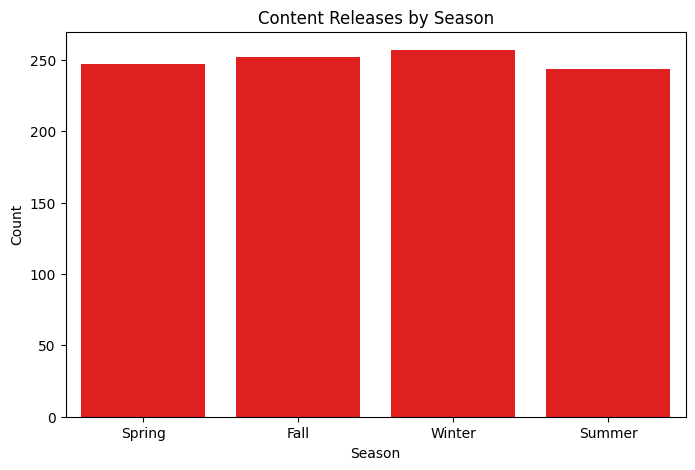

In [16]:
plt.figure(figsize=(8,5))
sns.countplot(x='season', data=df, color='red')
plt.title('Content Releases by Season')
plt.xlabel('Season')
plt.ylabel('Count')
plt.show()

## Bivariate Analysis

### 1. Viewership vs Day of release

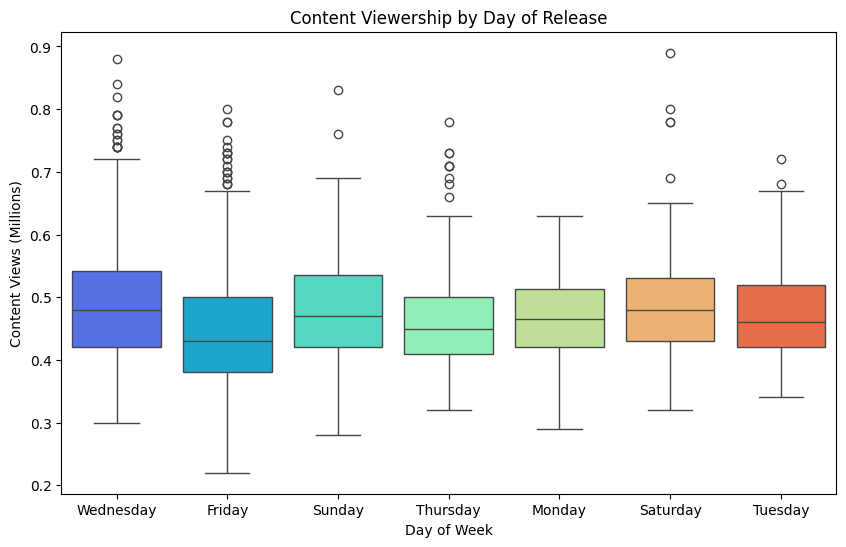

In [17]:
plt.figure(figsize=(10,6))
sns.boxplot(x='dayofweek', y='views_content', data=df, hue='dayofweek', palette='rainbow')
plt.title('Content Viewership by Day of Release')
plt.xlabel('Day of Week')
plt.ylabel('Content Views (Millions)')
plt.show()

In [18]:
avg_day_views = df.groupby('dayofweek')['views_content'].mean()
print("\nAverage Content Views by Day:")
print(avg_day_views)
print("\nInsight:")
print("Weekend releases generally receive higher engagement.")


Average Content Views by Day:
dayofweek
Friday       0.446694
Monday       0.467917
Saturday     0.497955
Sunday       0.484179
Thursday     0.470619
Tuesday      0.487826
Wednesday    0.494608
Name: views_content, dtype: float64

Insight:
Weekend releases generally receive higher engagement.


### 2. Viewership vs Season


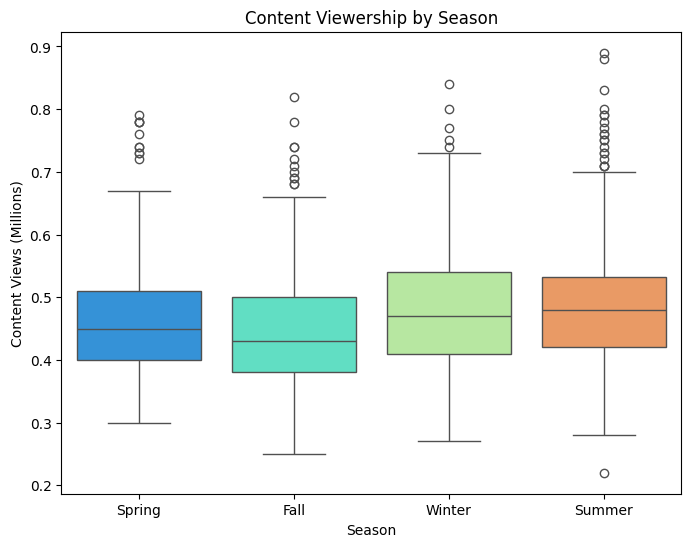

In [19]:
plt.figure(figsize=(8,6))
sns.boxplot(x='season', y='views_content', data=df, hue='season', palette='rainbow')
plt.title('Content Viewership by Season')
plt.xlabel('Season')
plt.ylabel('Content Views (Millions)')
plt.show()

In [20]:
avg_season_views = df.groupby('season')['views_content'].mean()
print("\nAverage Content Views by Season:")
print(avg_season_views)
print("\nInsight:")
print("Certain seasons show stronger audience engagement.")


Average Content Views by Season:
season
Fall      0.445357
Spring    0.467166
Summer    0.496803
Winter    0.484669
Name: views_content, dtype: float64

Insight:
Certain seasons show stronger audience engagement.


### 3. Trailer views vs Content views

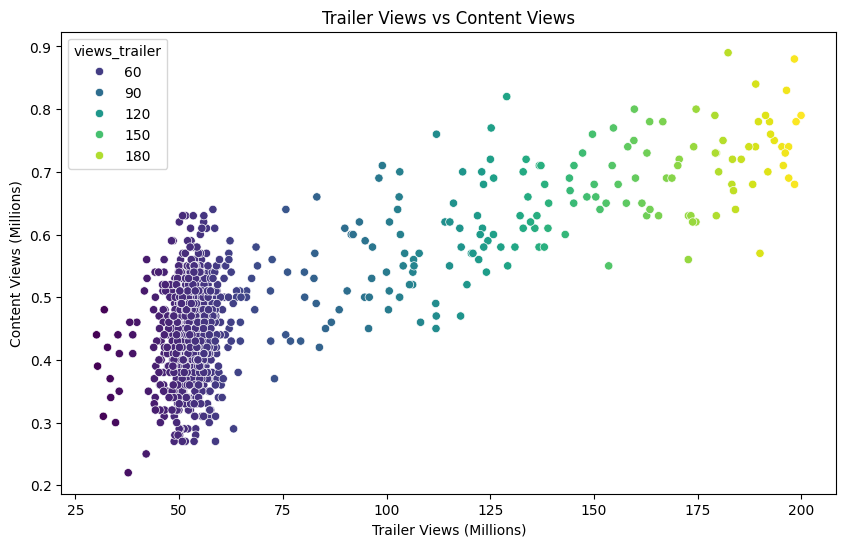

In [21]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='views_trailer', y='views_content', data=df, hue='views_trailer', palette='viridis')
plt.title('Trailer Views vs Content Views')
plt.xlabel('Trailer Views (Millions)')
plt.ylabel('Content Views (Millions)')
plt.show()


In [22]:
corr = df['views_trailer'].corr(df['views_content'])
print("\nCorrelation between Trailer Views and Content Views:")
print(round(corr, 3))
print("\nInsight:")
print("Higher trailer engagement leads to higher first-day content viewership.")


Correlation between Trailer Views and Content Views:
0.754

Insight:
Higher trailer engagement leads to higher first-day content viewership.


### 4. Visitors vs Content views

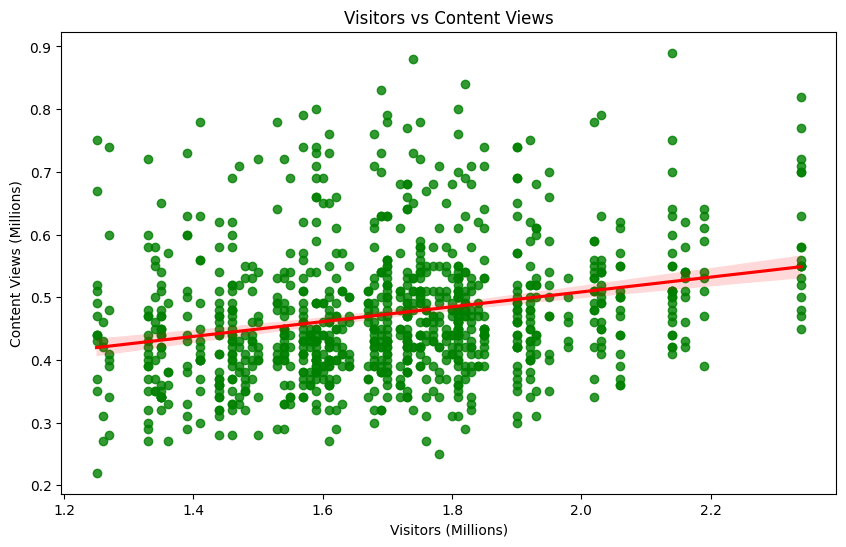

In [23]:
plt.figure(figsize=(10,6))
sns.regplot(x='visitors', y='views_content', data=df, color='green', line_kws={"color": "red"})
plt.title('Visitors vs Content Views')
plt.xlabel('Visitors (Millions)')
plt.ylabel('Content Views (Millions)')
plt.show()

### 5. AD impressions vs Content views

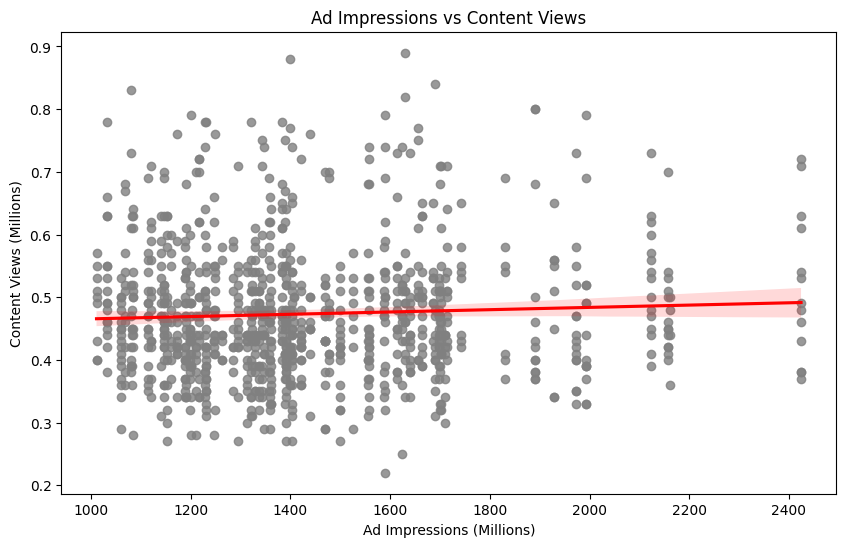

In [24]:
plt.figure(figsize=(10,6))
sns.regplot(x='ad_impressions', y='views_content', data=df, color='grey', line_kws={"color": "red"})
plt.title('Ad Impressions vs Content Views')
plt.xlabel('Ad Impressions (Millions)')
plt.ylabel('Content Views (Millions)')
plt.show()

### 6. Major sports event impact

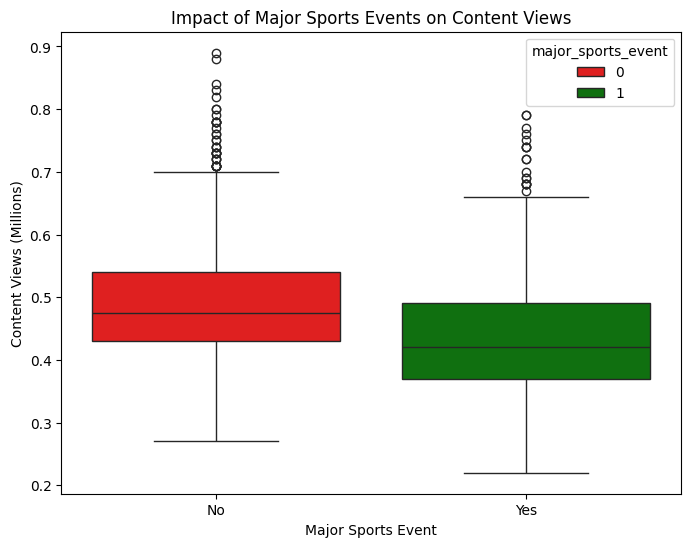


Insight:
Sports events negatively affect OTT content viewership.


In [25]:
plt.figure(figsize=(8,6))
custom_palette = {0: "red", 1: "green"}
sns.boxplot(x='major_sports_event', y='views_content', data=df, hue='major_sports_event', palette=custom_palette)
plt.title('Impact of Major Sports Events on Content Views')
plt.xlabel('Major Sports Event')
plt.ylabel('Content Views (Millions)')
plt.xticks([0,1], ['No', 'Yes'])
plt.show()

print("\nInsight:")
print("Sports events negatively affect OTT content viewership.")

### 7. Genre vs Content views

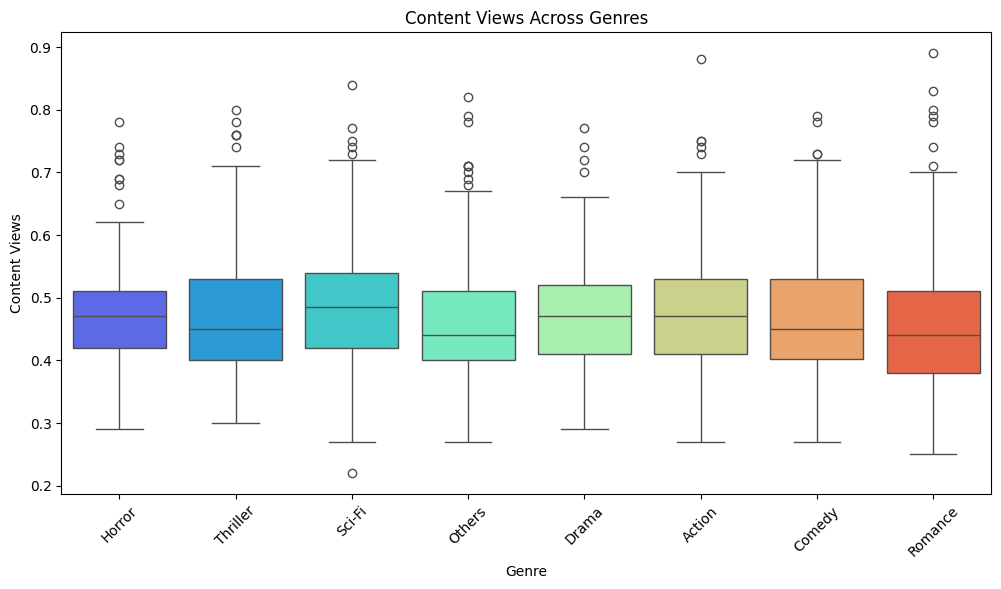

In [26]:
plt.figure(figsize=(12,6))
sns.boxplot(x='genre', y='views_content', data=df, hue='genre', palette='rainbow')
plt.title('Content Views Across Genres')
plt.xlabel('Genre')
plt.ylabel('Content Views')
plt.xticks(rotation=45)
plt.show()

## Correlation Analysis

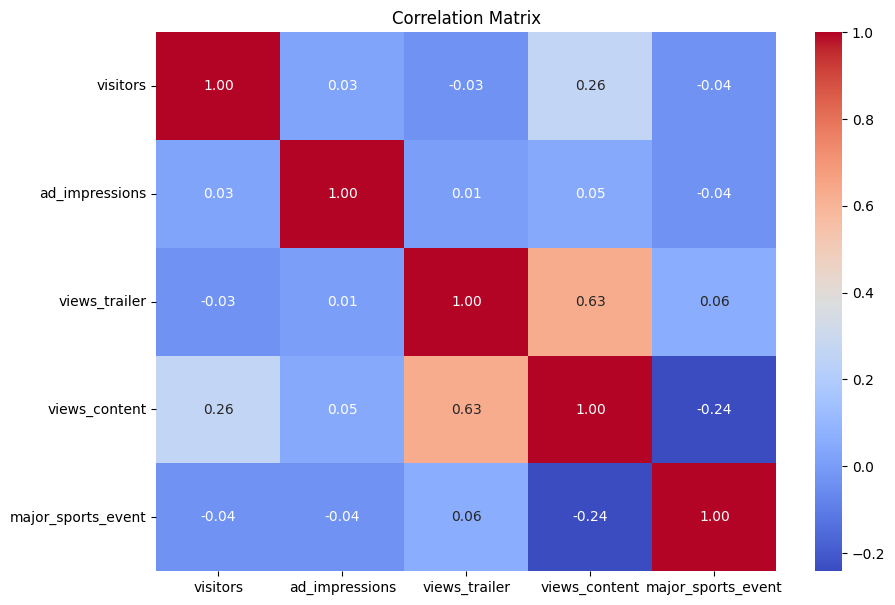

In [81]:
numerical_cols = ['visitors', 'ad_impressions', 'views_trailer', 'views_content', 'major_sports_event']
corr_matrix = df[numerical_cols].corr()
plt.figure(figsize=(10,7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

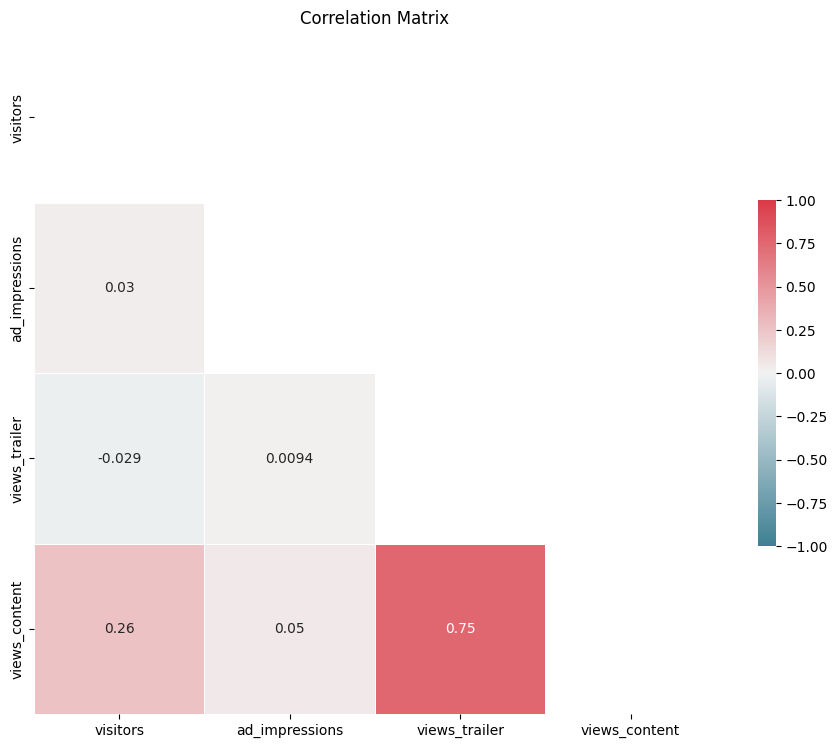

In [27]:
numerical_cols = ['visitors', 'ad_impressions', 'views_trailer', 'views_content']

corr = df[numerical_cols].corr()

# Generate a mask for the upper triangle; True = do NOT show
mask = np.zeros_like(corr, dtype=np.bool_)
mask[np.triu_indices_from(mask)] = True

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 9))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(220, 10, as_cmap=True)

sns.heatmap(corr, mask=mask, cmap=cmap, annot=True, vmax=1, vmin=-1, center=0, square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.title('Correlation Matrix')
plt.show()

## Answers to key questions

In [28]:
# 1. Distribution of Content Views

print("\n1. What does the distribution of content views look like?")
print("The distribution shows that most contents receive moderate first-day viewership.")


# 2. Distribution of Genres

print("\n2. What does the distribution of genres look like?")
print("The platform contains multiple genres with some genres dominating the release schedule.")


# 3. Viewership by Day of Release

print("\n3. The day of the week on which content is released generally plays a key role in the viewership. How does the viewership vary with the day of release?")
print(avg_day_views)

print("Weekend releases tend to perform better.")


# 4. Viewership by Season

print("\n4. How does the viewership vary with the season of release?")
print(avg_season_views)

print("Certain seasons show stronger audience engagement.")


# 5. Correlation between Trailer Views and Content Views

print("\n5. What is the correlation between trailer views and content views?")
print("Correlation:", round(corr,3))

print("Strong positive relationship exists.")


1. What does the distribution of content views look like?
The distribution shows that most contents receive moderate first-day viewership.

2. What does the distribution of genres look like?
The platform contains multiple genres with some genres dominating the release schedule.

3. The day of the week on which content is released generally plays a key role in the viewership. How does the viewership vary with the day of release?
dayofweek
Friday       0.446694
Monday       0.467917
Saturday     0.497955
Sunday       0.484179
Thursday     0.470619
Tuesday      0.487826
Wednesday    0.494608
Name: views_content, dtype: float64
Weekend releases tend to perform better.

4. How does the viewership vary with the season of release?
season
Fall      0.445357
Spring    0.467166
Summer    0.496803
Winter    0.484669
Name: views_content, dtype: float64
Certain seasons show stronger audience engagement.

5. What is the correlation between trailer views and content views?
Correlation:              

# Data preprocessing

## Duplicate value check

In [29]:
duplicate_count = df.duplicated().sum()
print("Number of Duplicate Rows:", duplicate_count)

Number of Duplicate Rows: 0


In [30]:
if duplicate_count > 0:

    df = df.drop_duplicates()

    print("Duplicates removed successfully.")

else:

    print("No duplicate values found.")

No duplicate values found.


## Missing value treatment

In [31]:
df.isnull().sum()

,0
visitors,0
ad_impressions,0
major_sports_event,0
genre,0
dayofweek,0
season,0
views_trailer,0
views_content,0


In [32]:
# Numerical columns
num_cols = df.select_dtypes(include=np.number).columns

# Categorical columns
cat_cols = df.select_dtypes(include='object').columns

# Fill numerical missing values with median
for col in num_cols:

    if df[col].isnull().sum() > 0:

        median_value = df[col].median()

        df[col].fillna(median_value, inplace=True)

# Fill categorical missing values with mode
for col in cat_cols:

    if df[col].isnull().sum() > 0:

        mode_value = df[col].mode()[0]

        df[col].fillna(mode_value, inplace=True)

print("\nMissing values treated successfully.")


Missing values treated successfully.


In [33]:
print("\nRemaining Missing Values:")
print(df.isnull().sum())


Remaining Missing Values:
visitors              0
ad_impressions        0
major_sports_event    0
genre                 0
dayofweek             0
season                0
views_trailer         0
views_content         0
dtype: int64


## Outlier treatment

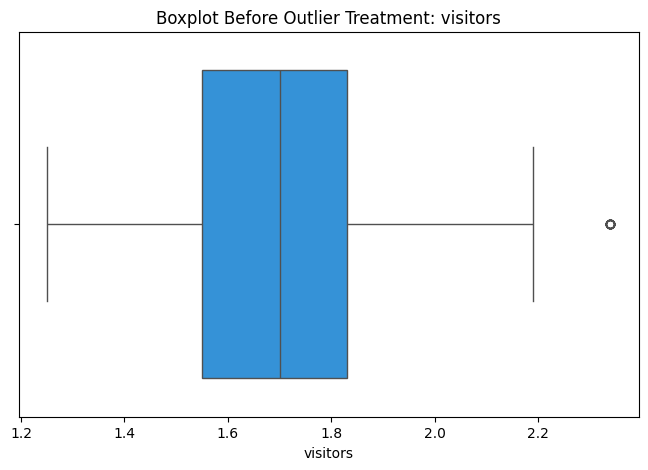

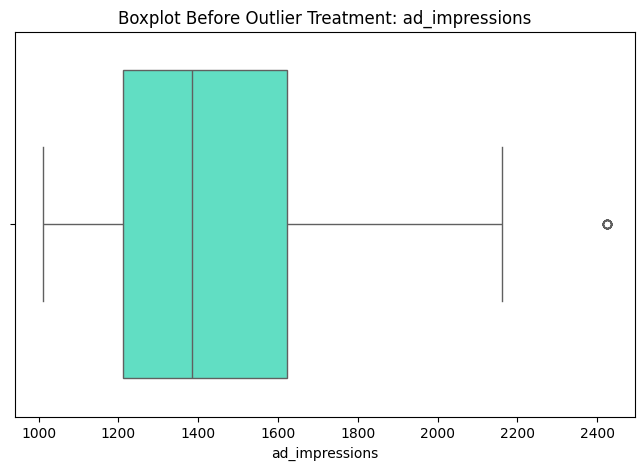

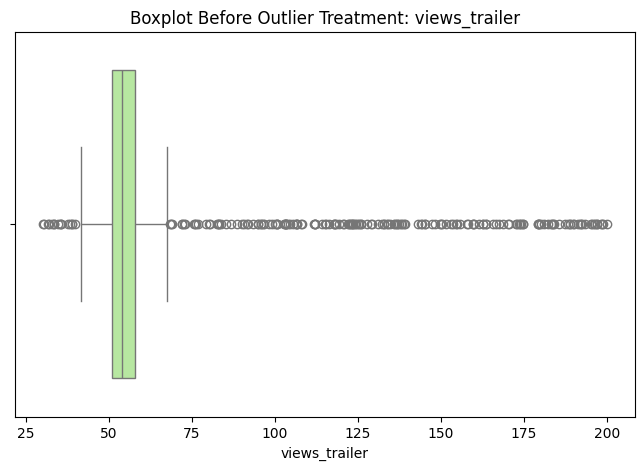

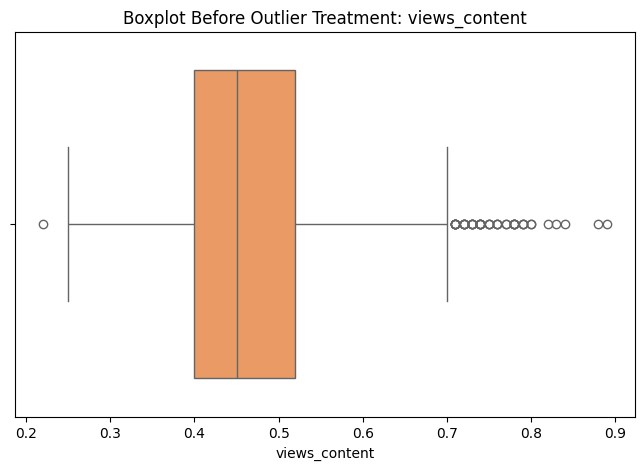

In [34]:
numerical_cols = ['visitors', 'ad_impressions', 'views_trailer', 'views_content']

# Get a list of distinct colors from a seaborn palette
colors = sns.color_palette('rainbow', len(numerical_cols))

for i, col in enumerate(numerical_cols):
    plt.figure(figsize=(8,5))
    # Assign a unique color to each boxplot
    sns.boxplot(x=df[col], color=colors[i])
    plt.title(f'Boxplot Before Outlier Treatment: {col}')
    plt.show()

In [35]:
def treat_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    # Capping outliers

    data[column] = np.where(data[column] < lower_limit, lower_limit, data[column])

    data[column] = np.where(data[column] > upper_limit, upper_limit, data[column])

    return data

# Apply outlier treatment

for col in numerical_cols:
    df = treat_outliers_iqr(df, col)

print("\nOutlier treatment completed successfully.")


Outlier treatment completed successfully.


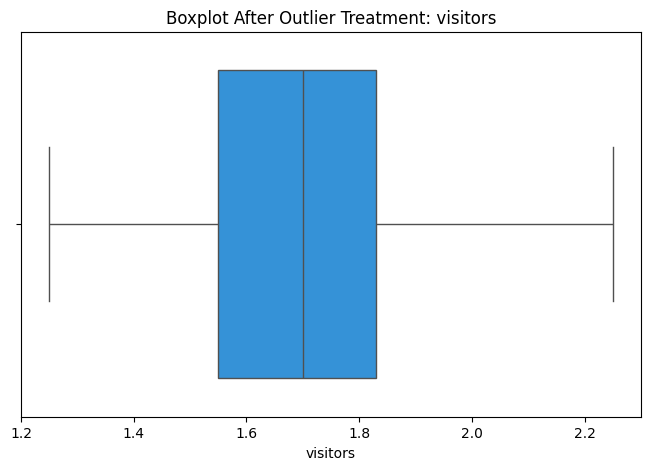

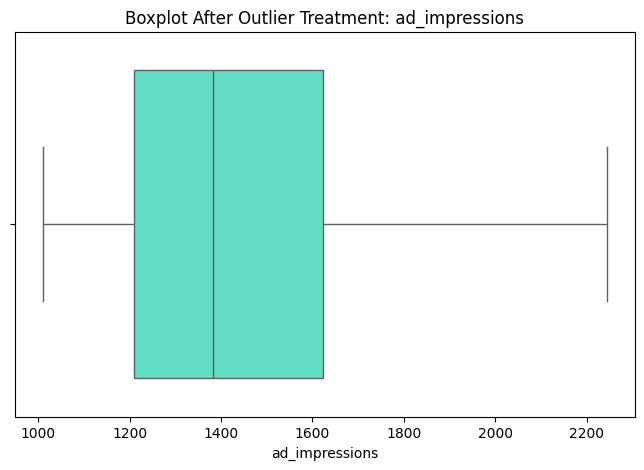

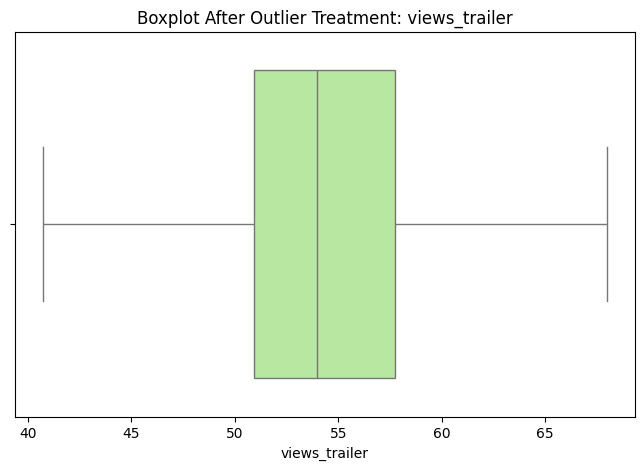

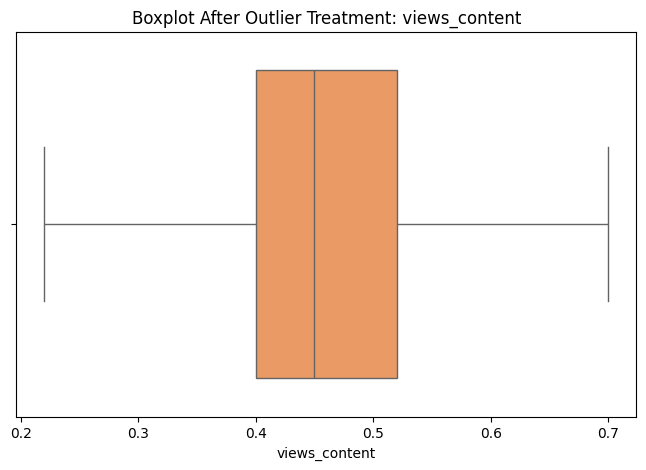

In [36]:
numerical_cols = ['visitors', 'ad_impressions', 'views_trailer', 'views_content']

# Get a list of distinct colors from a seaborn palette
colors = sns.color_palette('rainbow', len(numerical_cols))

for i, col in enumerate(numerical_cols):

    plt.figure(figsize=(8,5))
    # Assign a unique color to each boxplot
    sns.boxplot(x=df[col], color=colors[i])
    plt.title(f'Boxplot After Outlier Treatment: {col}')
    plt.show()

## Feature engineering

In [37]:
# Encode Major Sports Event

df['major_sports_event'] = df['major_sports_event'].astype(int)

# One-Hot Encoding for Categorical Variables
df_encoded = pd.get_dummies( df, columns=['genre', 'dayofweek', 'season'], drop_first=True)

print("\nEncoded Dataset Shape:")
print(df_encoded.shape)

# Display columns
print("\nEncoded Columns:")
print(df_encoded.columns)


Encoded Dataset Shape:
(1000, 21)

Encoded Columns:
Index(['visitors', 'ad_impressions', 'major_sports_event', 'views_trailer',
       'views_content', 'genre_Comedy', 'genre_Drama', 'genre_Horror',
       'genre_Others', 'genre_Romance', 'genre_Sci-Fi', 'genre_Thriller',
       'dayofweek_Monday', 'dayofweek_Saturday', 'dayofweek_Sunday',
       'dayofweek_Thursday', 'dayofweek_Tuesday', 'dayofweek_Wednesday',
       'season_Spring', 'season_Summer', 'season_Winter'],
      dtype='object')


##  Data preparation for modeling

In [38]:
# DEFINE FEATURES AND TARGET

X = df_encoded.drop('views_content', axis=1)
y = df_encoded['views_content']

print("\nFeature Variables Shape:", X.shape)
print("Target Variable Shape:", y.shape)


Feature Variables Shape: (1000, 20)
Target Variable Shape: (1000,)


In [39]:
# TRAIN-TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("\nTraining Data Shape:")
print(X_train.shape)

print("\nTesting Data Shape:")
print(X_test.shape)


Training Data Shape:
(800, 20)

Testing Data Shape:
(200, 20)


In [40]:
# FEATURE SCALING

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeature Scaling Completed Successfully.")


Feature Scaling Completed Successfully.


In [41]:
# FINAL PREPROCESSED DATA

print("\nTraining Features:")
print(X_train_scaled[:5])

print("\nTraining Target:")
print(y_train.head())


Training Features:
[[-2.03053884  0.98629236  1.21207912 -0.16029908 -0.34705645 -0.3560345
  -0.3560345   1.73784364 -0.3560345  -0.32634444 -0.35380193 -0.15171652
   3.36269123 -0.27170849 -0.34251779 -0.14734777 -0.70379479  1.72629647
  -0.5658021  -0.58889842]
 [-0.48581549 -0.33508727 -0.82502865  0.00865173 -0.34705645 -0.3560345
  -0.3560345   1.73784364 -0.3560345  -0.32634444 -0.35380193 -0.15171652
  -0.29738086 -0.27170849 -0.34251779 -0.14734777 -0.70379479 -0.57927478
  -0.5658021   1.69808573]
 [ 0.04380394 -0.14264373 -0.82502865  1.78570385 -0.34705645  2.80871659
  -0.3560345  -0.57542576 -0.3560345  -0.32634444 -0.35380193 -0.15171652
  -0.29738086 -0.27170849 -0.34251779 -0.14734777 -0.70379479 -0.57927478
  -0.5658021  -0.58889842]
 [ 0.926503   -0.48131043 -0.82502865  0.03464417 -0.34705645 -0.3560345
  -0.3560345  -0.57542576 -0.3560345  -0.32634444  2.82644017 -0.15171652
   3.36269123 -0.27170849 -0.34251779 -0.14734777 -0.70379479  1.72629647
  -0.5658021  

# Model building - Linear Regression

## Data preparation

In [42]:
df_encoded = pd.get_dummies(df, columns=['genre', 'dayofweek', 'season'], drop_first=True)
X = df_encoded.drop('views_content', axis=1)
y = df_encoded['views_content']

In [43]:
# Train Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [44]:
# Feture scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrame, preserving original indices

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)

X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

In [45]:
# Add constant term
X_train_sm = sm.add_constant(X_train_scaled)
X_test_sm = sm.add_constant(X_test_scaled)

In [46]:
# Build linear regression model
model = sm.OLS(y_train, X_train_sm).fit()

## Model summary

In [47]:
print("LINEAR REGRESSION MODEL SUMMARY")
model.summary()

LINEAR REGRESSION MODEL SUMMARY


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          views_content   R-squared:                       0.622
Model:                            OLS   Adj. R-squared:                  0.612
Method:                 Least Squares   F-statistic:                     64.05
Date:                Fri, 22 May 2026   Prob (F-statistic):          2.85e-149
Time:                        17:46:24   Log-Likelihood:                 1109.8
No. Observations:                 800   AIC:                            -2178.
Df Residuals:                     779   BIC:                            -2079.
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.4721      0.002    218.022      0.000       0.468       0.476
visitors                0.0290      0.002     13.249      0.000       0.025       0.033
ad_impressions          0.0011      0.002      0.487      0.626      -0.003       0.005
major_sports_event     -0.0277      0.002    -12.472      0.000      -0.032      -0.023
views_trailer           0.0632      0.002     28.859      0.000       0.059       0.068
genre_Comedy           -0.0009      0.003     -0.293      0.770      -0.007       0.005
genre_Drama             0.0015      0.003      0.504      0.614      -0.004       0.007
genre_Horror           -0.0003      0.003     -0.094      0.925      -0.006       0.006
genre_Others           -0.0008      0.004     -0.236      0.813      -0.008       0.006
genre_Romance          -0.0030      0.003     -0.979      0.328      -0.009       0.003
genre_Sci-Fi            0.0045      0.003      1.517      0.130      -0.001       0.010
genre_Thriller          0.0020      0.003      0.650      0.516      -0.004       0.008
dayofweek_Monday        0.0053      0.002      2.371      0.018       0.001       0.010
dayofweek_Saturday      0.0124      0.002      5.367      0.000       0.008       0.017
dayofweek_Sunday        0.0097      0.002      4.238      0.000       0.005       0.014
dayofweek_Thursday      0.0065      0.002      2.796      0.005       0.002       0.011
dayofweek_Tuesday       0.0054      0.002      2.428      0.015       0.001       0.010
dayofweek_Wednesday     0.0209      0.002      8.495      0.000       0.016       0.026
season_Spring           0.0098      0.003      3.666      0.000       0.005       0.015
season_Summer           0.0173      0.003      6.368      0.000       0.012       0.023
season_Winter           0.0122      0.003      4.504      0.000       0.007       0.017
==============================================================================
Omnibus:                        8.940   Durbin-Watson:                   2.066
Prob(Omnibus):                  0.011   Jarque-Bera (JB):                9.119
Skew:                           0.251   Prob(JB):                       0.0105
Kurtosis:                       2.855   Cond. No.                         3.65
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [48]:
# Model predicitions
y_pred = model.predict(X_test_sm)

In [49]:
# Model evaluation
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

In [50]:
# Display model statistics
print("MODEL PERFORMANCE METRICS")
print(f"R-Squared   : {round(r2,4)}")
print(f"RMSE        : {round(rmse,4)}")
print(f"MAE         : {round(mae,4)}")

MODEL PERFORMANCE METRICS
R-Squared   : 0.6044
RMSE        : 0.0632
MAE         : 0.049


## Display model coefficients

In [51]:
coefficients = pd.DataFrame({'Feature': X_train_sm.columns, 'Coefficient': model.params.values, 'P-Value': model.pvalues.values})
coefficients = coefficients.sort_values(by='Coefficient', ascending=False)

In [52]:
print("MODEL COEFFICIENTS WITH COLUMN NAMES")
print(coefficients)

MODEL COEFFICIENTS WITH COLUMN NAMES
                Feature  Coefficient        P-Value
0                 const     0.472112   0.000000e+00
4         views_trailer     0.063211  3.999554e-125
1              visitors     0.029013   2.797074e-36
17  dayofweek_Wednesday     0.020905   9.961731e-17
19        season_Summer     0.017281   3.265043e-10
13   dayofweek_Saturday     0.012379   1.058855e-07
20        season_Winter     0.012181   7.675032e-06
18        season_Spring     0.009842   2.627319e-04
14     dayofweek_Sunday     0.009728   2.528213e-05
15   dayofweek_Thursday     0.006537   5.305617e-03
16    dayofweek_Tuesday     0.005419   1.541416e-02
12     dayofweek_Monday     0.005272   1.800530e-02
10         genre_Sci-Fi     0.004458   1.297146e-01
11       genre_Thriller     0.001968   5.157378e-01
6           genre_Drama     0.001525   6.141775e-01
2        ad_impressions     0.001063   6.263417e-01
7          genre_Horror    -0.000286   9.248593e-01
8          genre_Others    

In [53]:
print("TOP IMPORTANT DRIVER VARIABLES")
important_features = coefficients[coefficients['P-Value'] < 0.05]
print(important_features)

TOP IMPORTANT DRIVER VARIABLES
                Feature  Coefficient        P-Value
0                 const     0.472112   0.000000e+00
4         views_trailer     0.063211  3.999554e-125
1              visitors     0.029013   2.797074e-36
17  dayofweek_Wednesday     0.020905   9.961731e-17
19        season_Summer     0.017281   3.265043e-10
13   dayofweek_Saturday     0.012379   1.058855e-07
20        season_Winter     0.012181   7.675032e-06
18        season_Spring     0.009842   2.627319e-04
14     dayofweek_Sunday     0.009728   2.528213e-05
15   dayofweek_Thursday     0.006537   5.305617e-03
16    dayofweek_Tuesday     0.005419   1.541416e-02
12     dayofweek_Monday     0.005272   1.800530e-02
3    major_sports_event    -0.027698   1.115396e-32


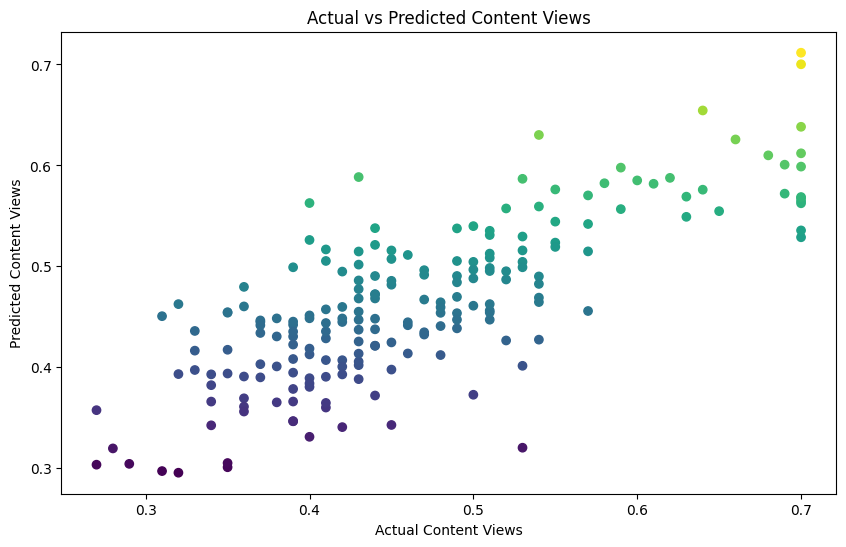

In [54]:
# Actual vs Predicted plot

plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, c=y_pred)
plt.xlabel('Actual Content Views')
plt.ylabel('Predicted Content Views')
plt.title('Actual vs Predicted Content Views')
plt.show()

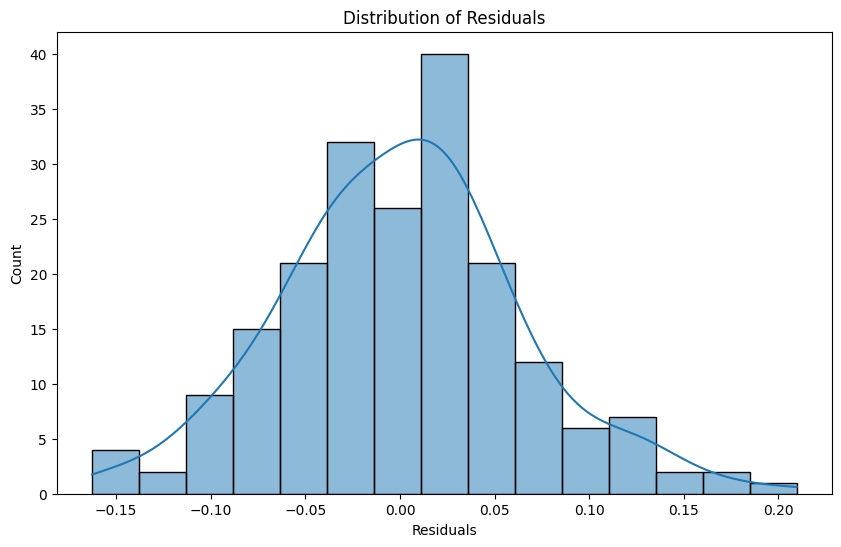

In [55]:
# Residual distribution

residuals = y_test - y_pred
plt.figure(figsize=(10,6))
sns.histplot(residuals, kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Residuals')
plt.show()

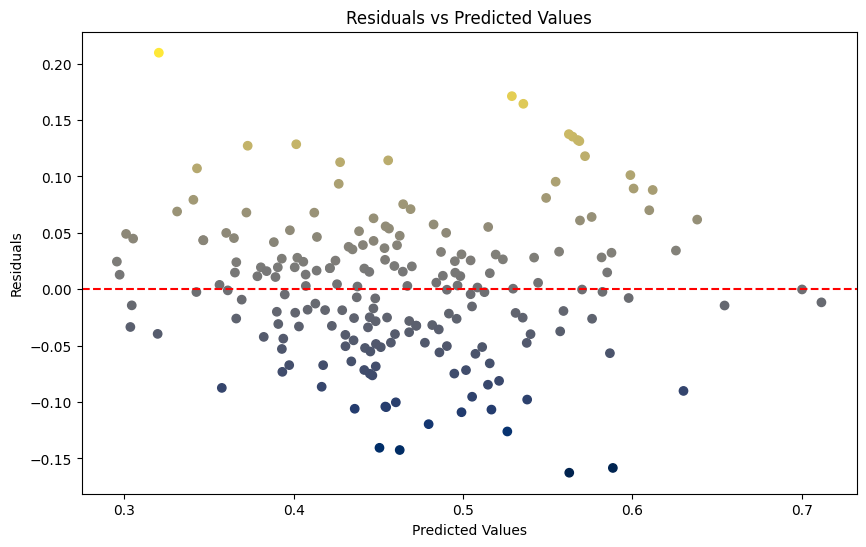

In [56]:
# Residual vs Predicted

plt.figure(figsize=(10,6))
plt.scatter(y_pred, residuals, c=residuals, cmap='cividis')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')
plt.show()

# Testing the assumptions of linear regression model

## Data preparation

In [57]:
df_encoded = pd.get_dummies(df, columns=['genre', 'dayofweek', 'season'], drop_first=True)
X = df_encoded.drop('views_content', axis=1)
y = df_encoded['views_content']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to DataFrame, preserving original indices

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

X_train_sm = sm.add_constant(X_train_scaled)
X_test_sm = sm.add_constant(X_test_scaled)

model = sm.OLS(y_train, X_train_sm).fit()

# Predictions
y_pred = model.predict(X_test_sm)

# Residuals
residuals = y_test - y_pred

## Assumption 1: Linearity

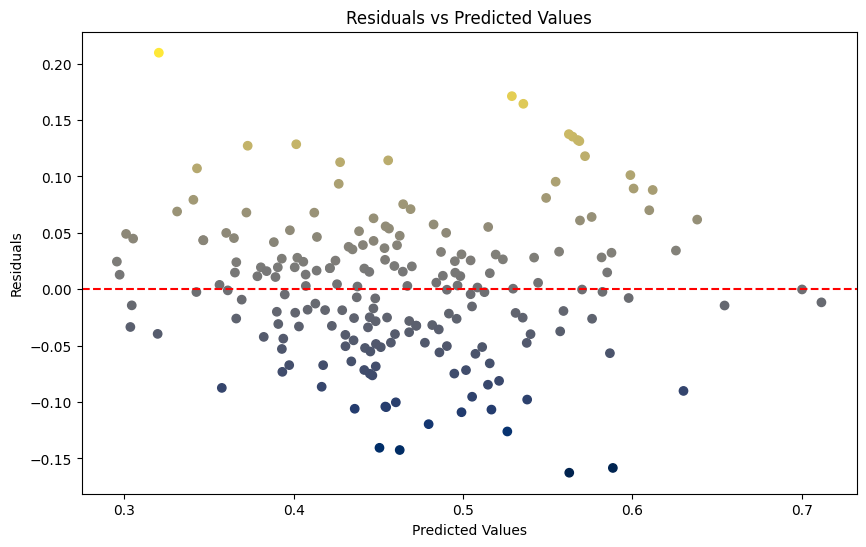


Interpretation:
- Residuals should be randomly scattered around zero.
- No visible pattern indicates linearity assumption is satisfied.



In [58]:
# Residual vs Predicted Plot

plt.figure(figsize=(10,6))
plt.scatter(y_pred, residuals, c=residuals, cmap='cividis')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')
plt.show()

print("""
Interpretation:
- Residuals should be randomly scattered around zero.
- No visible pattern indicates linearity assumption is satisfied.
""")

## Assumption 2: Normality of Residuals



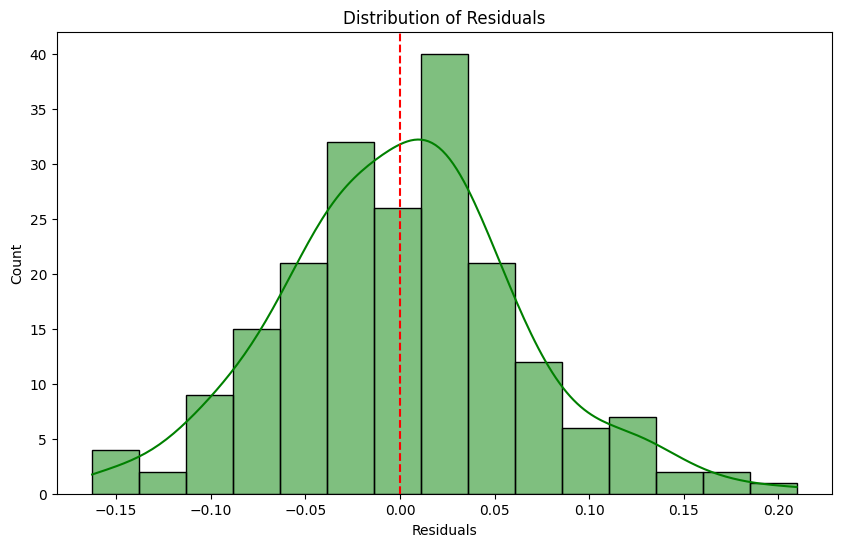

In [59]:
# Histogram of residuals

plt.figure(figsize=(10,6))
sns.histplot(residuals, kde=True, color='green')
plt.axvline(x=0, color='red', linestyle='--')
plt.title('Distribution of Residuals')
plt.xlabel('Residuals')
plt.show()

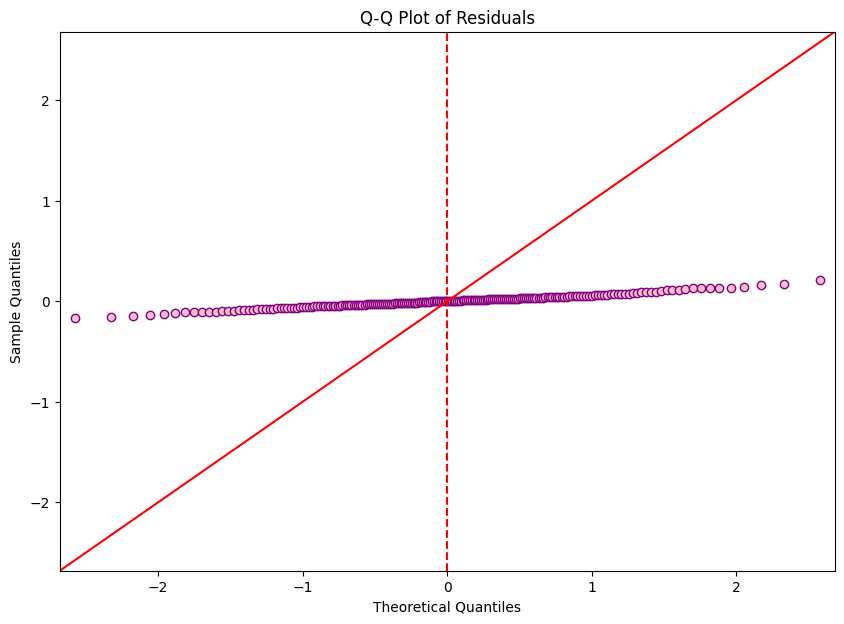

In [60]:
# Q-Q Plot

fig, ax = plt.subplots(figsize=(10, 7))
sm.qqplot(residuals, line='45', ax=ax)
plt.axvline(x=0, color='red', linestyle='--')
# ax.lines[0] usually refers to the data points in sm.qqplot
ax.lines[0].set_markerfacecolor('pink')
ax.lines[0].set_markeredgecolor('purple') # Set edge color for consistency
plt.title('Q-Q Plot of Residuals')
plt.show()

In [61]:
# Shapiro-Wilk Test
stat, p_value = shapiro(residuals)
print("Shapiro-Wilk Test Statistic:", round(stat,4))
print("P-value:", round(p_value,4))

Shapiro-Wilk Test Statistic: 0.9922
P-value: 0.3645


In [62]:
if p_value > 0.05:
    print("""
Conclusion:
Residuals are normally distributed.
Normality assumption is satisfied.
""")
else:
    print("""
Conclusion:
Residuals are NOT normally distributed.
Normality assumption is violated.
""")


Conclusion:
Residuals are normally distributed.
Normality assumption is satisfied.



## Assumption 3: Homoscedasticity

In [63]:
# Breusch-Pagan Test

bp_test = het_breuschpagan(residuals, X_test_sm)

bp_labels = [
    'Lagrange Multiplier Statistic',
    'P-value',
    'F-statistic',
    'F-test P-value'
]

print(dict(zip(bp_labels, bp_test)))

{'Lagrange Multiplier Statistic': np.float64(32.238205454924575), 'P-value': np.float64(0.04082530831115761), 'F-statistic': np.float64(1.7198906318568858), 'F-test P-value': np.float64(0.03368461568378147)}


In [64]:
# Interpretation

if bp_test[1] > 0.05:
    print("""
Conclusion:
Homoscedasticity assumption is satisfied.
Variance of residuals is constant.
""")

else:
    print("""
Conclusion:
Heteroscedasticity detected.
Variance of residuals is not constant.
""")


Conclusion:
Heteroscedasticity detected.
Variance of residuals is not constant.



## Assumption 4: Multicollinearity

In [65]:
# Calculate VIF

vif_data = pd.DataFrame()
vif_data["Feature"] = X_train_sm.columns
vif_data["VIF"] = [variance_inflation_factor( X_train_sm.values, i) for i in range(X_train_sm.shape[1])]

print(vif_data)

                Feature       VIF
0                 const  1.000000
1              visitors  1.022671
2        ad_impressions  1.016695
3    major_sports_event  1.051825
4         views_trailer  1.023142
5          genre_Comedy  1.893001
6           genre_Drama  1.949123
7          genre_Horror  1.957056
8          genre_Others  2.744608
9         genre_Romance  1.951451
10         genre_Sci-Fi  1.841998
11       genre_Thriller  1.952752
12     dayofweek_Monday  1.054613
13   dayofweek_Saturday  1.134732
14     dayofweek_Sunday  1.123843
15   dayofweek_Thursday  1.166108
16    dayofweek_Tuesday  1.062378
17  dayofweek_Wednesday  1.291416
18        season_Spring  1.536915
19        season_Summer  1.570450
20        season_Winter  1.559595


In [66]:
# Interpretation

print("""
Interpretation:
- VIF < 5  → No multicollinearity concern
- VIF 5-10 → Moderate multicollinearity
- VIF > 10 → Serious multicollinearity issue
""")


Interpretation:
- VIF < 5  → No multicollinearity concern
- VIF 5-10 → Moderate multicollinearity
- VIF > 10 → Serious multicollinearity issue



## Assumption 5: Independence of errors

In [67]:
durbin_watson = sm.stats.stattools.durbin_watson(residuals)
print("Durbin-Watson Statistic:", round(durbin_watson,4))

Durbin-Watson Statistic: 1.8911


In [68]:
# Interpretation

if 1.5 <= durbin_watson <= 2.5:
    print("""
Conclusion:
Residuals are independent.
No autocorrelation detected.
""")

else:
    print("""
Conclusion:
Autocorrelation may exist in residuals.
Independence assumption may be violated.
""")


Conclusion:
Residuals are independent.
No autocorrelation detected.



## Assumption 6: Outlier influence

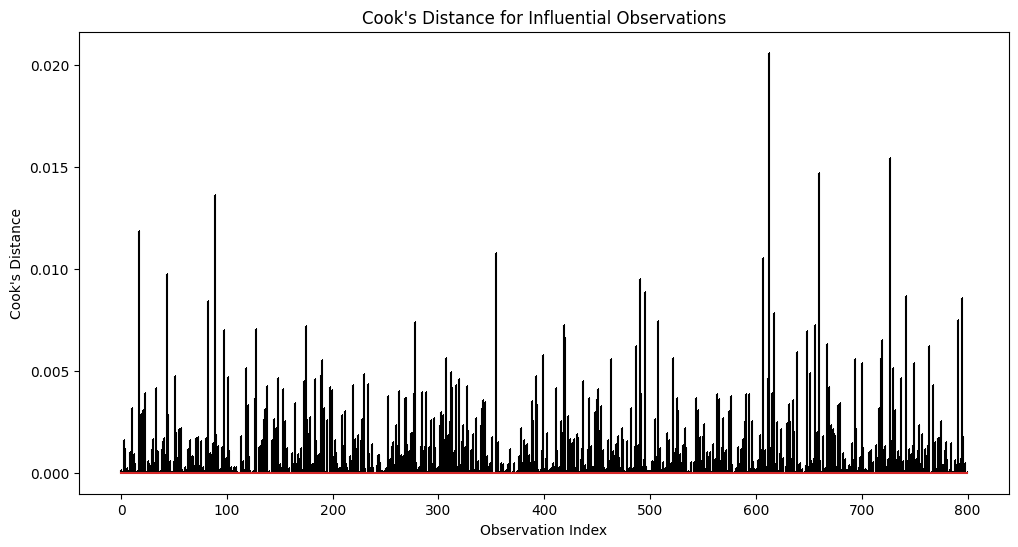

In [69]:
# Cook's Distance

influence = model.get_influence()
cooks = influence.cooks_distance[0]

# Plot Cook's Distance

plt.figure(figsize=(12,6))
plt.stem(np.arange(len(cooks)), cooks, markerfmt=",", linefmt='Black')
plt.title("Cook's Distance for Influential Observations")
plt.xlabel("Observation Index")
plt.ylabel("Cook's Distance")
plt.show()

In [70]:
# Threshold

threshold = 4 / len(cooks)
print("Cook's Distance Threshold:", round(threshold,4))

Cook's Distance Threshold: 0.005


In [71]:
# Influential observations

influential_points = np.where(cooks > threshold)[0]
print("Number of Influential Points:",
      len(influential_points))

print("""
Interpretation:
- Very few influential points indicate stable model performance.
""")

Number of Influential Points: 40

Interpretation:
- Very few influential points indicate stable model performance.



# Model performance evaluation

## Data preparation

In [72]:
df_encoded = pd.get_dummies(df, columns=['genre', 'dayofweek', 'season'], drop_first=True)

# Features and target variable
X = df_encoded.drop('views_content', axis=1)
y = df_encoded['views_content']

# TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# FEATURE SCALING
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert into DataFrame, preserving original indices
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

# ADD CONSTANT
X_train_sm = sm.add_constant(X_train_scaled)
X_test_sm = sm.add_constant(X_test_scaled)

# BUILD MODEL
model = sm.OLS(y_train, X_train_sm).fit()

# PREDICTIONS
y_train_pred = model.predict(X_train_sm)
y_test_pred = model.predict(X_test_sm)

## Performance metrics

In [73]:
# TRAINING PERFORMANCE METRICS

train_r2 = r2_score(y_train, y_train_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))

train_mae = mean_absolute_error(y_train, y_train_pred)

train_mape = mean_absolute_percentage_error(y_train, y_train_pred)


In [74]:
# TESTING PERFORMANCE METRICS

test_r2 = r2_score(y_test, y_test_pred)

test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

test_mae = mean_absolute_error(y_test, y_test_pred)

test_mape = mean_absolute_percentage_error(y_test, y_test_pred)


In [75]:
# DISPLAY MODEL PERFORMANCE

print("LINEAR REGRESSION MODEL PERFORMANCE")

performance_df = pd.DataFrame({'Metric': ['R-Squared', 'RMSE', 'MAE', 'MAPE'],
    'Training Data': [
        round(train_r2,4),
        round(train_rmse,4),
        round(train_mae,4),
        round(train_mape,4)],

    'Testing Data': [
        round(test_r2,4),
        round(test_rmse,4),
        round(test_mae,4),
        round(test_mape,4)]})

print(performance_df)

LINEAR REGRESSION MODEL PERFORMANCE
      Metric  Training Data  Testing Data
0  R-Squared         0.6218        0.6044
1       RMSE         0.0604        0.0632
2        MAE         0.0484        0.0490
3       MAPE         0.1050        0.1086


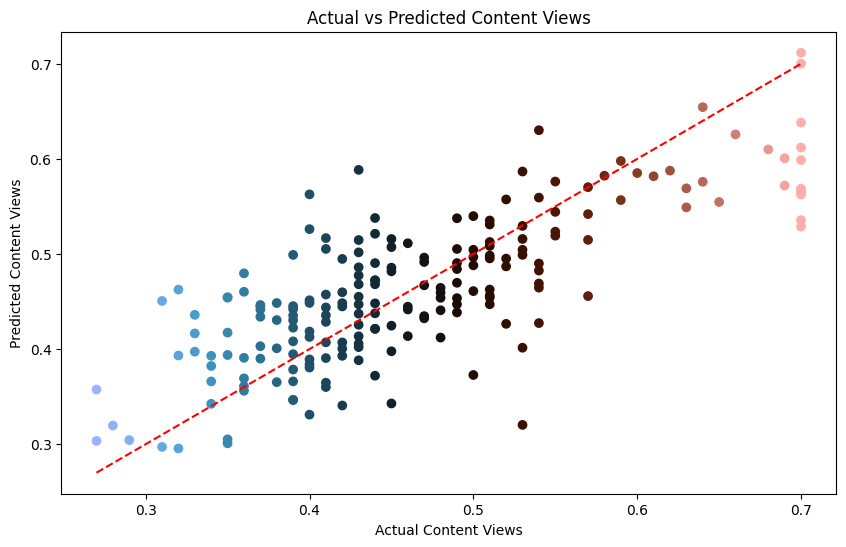

In [76]:
# ACTUAL VS PREDICTED VALUES

plt.figure(figsize=(10,6))
plt.scatter(y_test, y_test_pred, c=y_test, cmap='berlin')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Content Views')
plt.ylabel('Predicted Content Views')
plt.title('Actual vs Predicted Content Views')
plt.show()

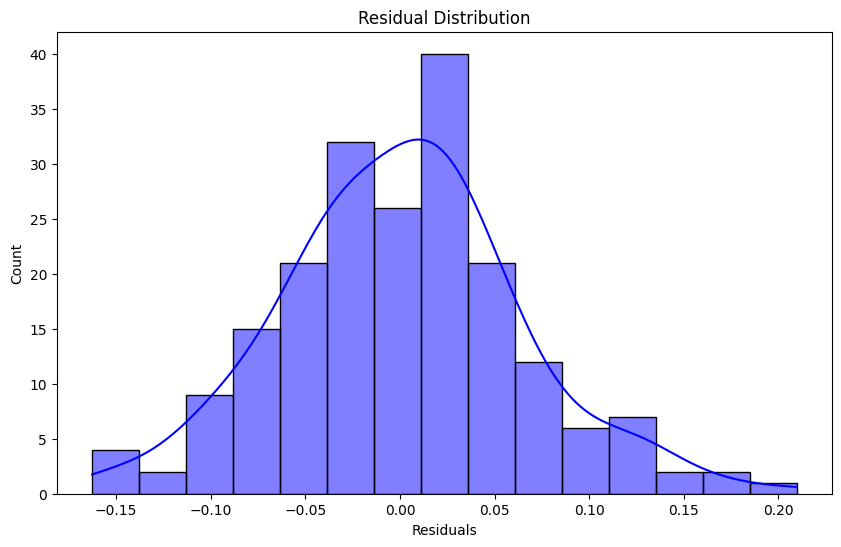

In [77]:
# RESIDUAL ANALYSIS

residuals = y_test - y_test_pred

# Histogram of residuals

plt.figure(figsize=(10,6))
sns.histplot(residuals, kde=True, color='blue')
plt.title('Residual Distribution')
plt.xlabel('Residuals')
plt.show()

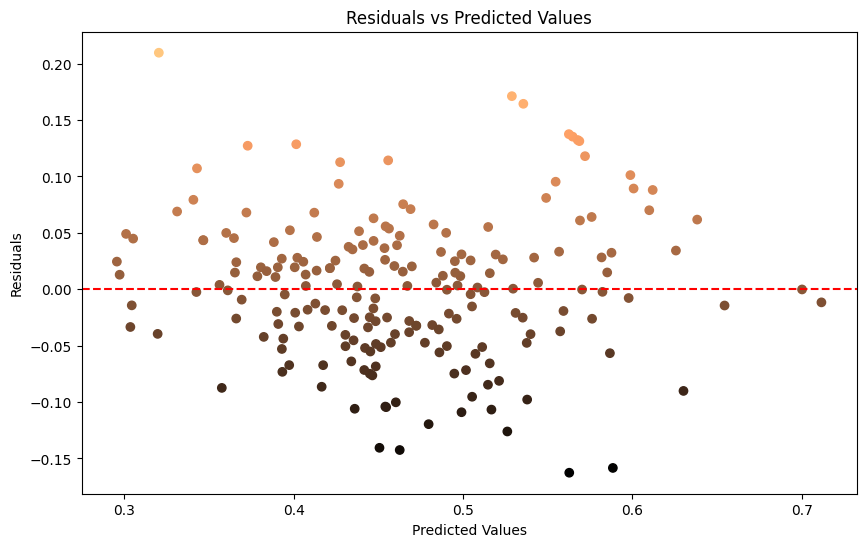

In [78]:
# RESIDUALS VS PREDICTED VALUES

plt.figure(figsize=(10,6))
plt.scatter(y_test_pred, residuals, c=residuals, cmap='copper')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')
plt.show()

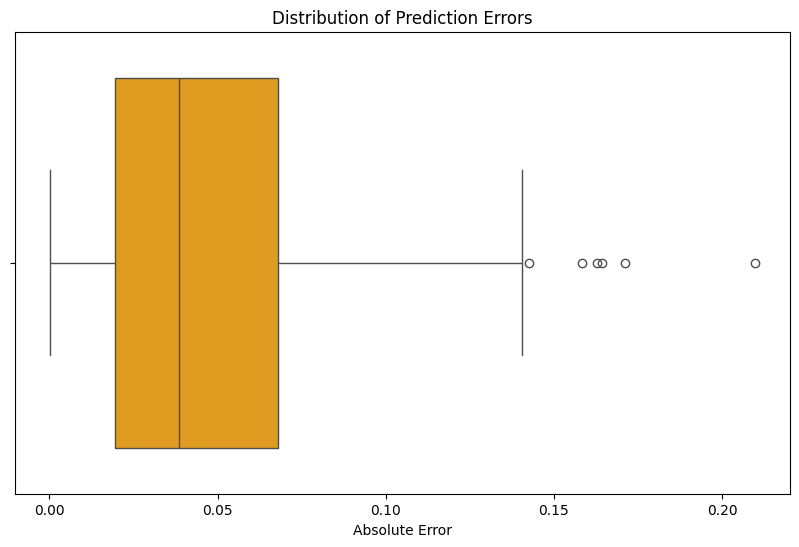

In [79]:
# ERROR DISTRIBUTION

errors = abs(y_test - y_test_pred)
plt.figure(figsize=(10,6))
sns.boxplot(x=errors, color='orange')
plt.title('Distribution of Prediction Errors')
plt.xlabel('Absolute Error')
plt.show()

In [80]:
# FEATURE IMPORTANCE

coefficients = pd.DataFrame({'Feature': X_train_sm.columns, 'Coefficient': model.params.values})
coefficients = coefficients.sort_values(by='Coefficient', ascending=False)

print("TOP MODEL DRIVER VARIABLES")
print(coefficients.head(10))

TOP MODEL DRIVER VARIABLES
                Feature  Coefficient
0                 const     0.472112
4         views_trailer     0.063211
1              visitors     0.029013
17  dayofweek_Wednesday     0.020905
19        season_Summer     0.017281
13   dayofweek_Saturday     0.012379
20        season_Winter     0.012181
18        season_Spring     0.009842
14     dayofweek_Sunday     0.009728
15   dayofweek_Thursday     0.006537
